In [1]:
%matplotlib inline
from pylab import *

In [2]:
from deficit_defs import *
from input_environment_defs import *

Splikes version  0.1.4
Plasticnet version  0.1.13
macOS-15.4.1-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [14]:
def get_input_examples(im1,im2,
                       noise1=0.1,noise2=0.1,
                       scale1=1,scale2=1,
                     mu_c=0,sigma_c=0,    
                     mu_r=0,sigma_r=0,    
                     base_image_file='asdf/bbsk081604_all_scale2.asdf',
                       N=100,
                ):
    
    rf_size=19
    eta=2e-6
    pre1=pn.neurons.natural_images_with_jitter(im1,
                                   rf_size=rf_size,
                                    sigma_r=0,
                                   sigma_c=0,
                                   verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im2,
                                               rf_size=rf_size,
                                other_channel=pre1,
                               mu_r=mu_r,mu_c=mu_c,
                               sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.scale_shift(scale1,0)
    pre2+=pn.neurons.process.scale_shift(scale2,0)

    pre1+=pn.neurons.process.add_noise_normal(0,noise1)
    pre2+=pn.neurons.process.add_noise_normal(0,noise2)

    pre=pre1+pre2

    sim=pn.simulation(N)
    sim.monitor(pre,['output'],1)
    sim.monitor(pre1,['pattern','p','c','r','pa','ca','ra'],1)
    sim.monitor(pre2,['pattern','p','c','r','pa','ca','ra'],1)

    pn.run_sim(sim,[pre],[],display_hash=False,print_time=False)

    m=sim.monitors['output']
    
    t,X=m.arrays()
    
    
    X=X[1:,:]

    
    
    return sim,X
    

In [52]:
im1=im2=pi5.filtered_images(
                    base_image_file,
                    {'type':'dog','sd1':1,'sd2':3},
                    {'type':'norm'},
                    )

mu_r,mu_c=0,9
sigma_r,sigma_c=9,9

sim,X=get_input_examples(im1,im2,
                        noise1=0,noise2=0,
                        mu_r=mu_r,mu_c=mu_c,sigma_r=sigma_r,sigma_c=sigma_c,                         
                        N=1000)

Using cache_images/cache_images_f6d484251bbeda8699ed0b15303a996c.asdf from cache.

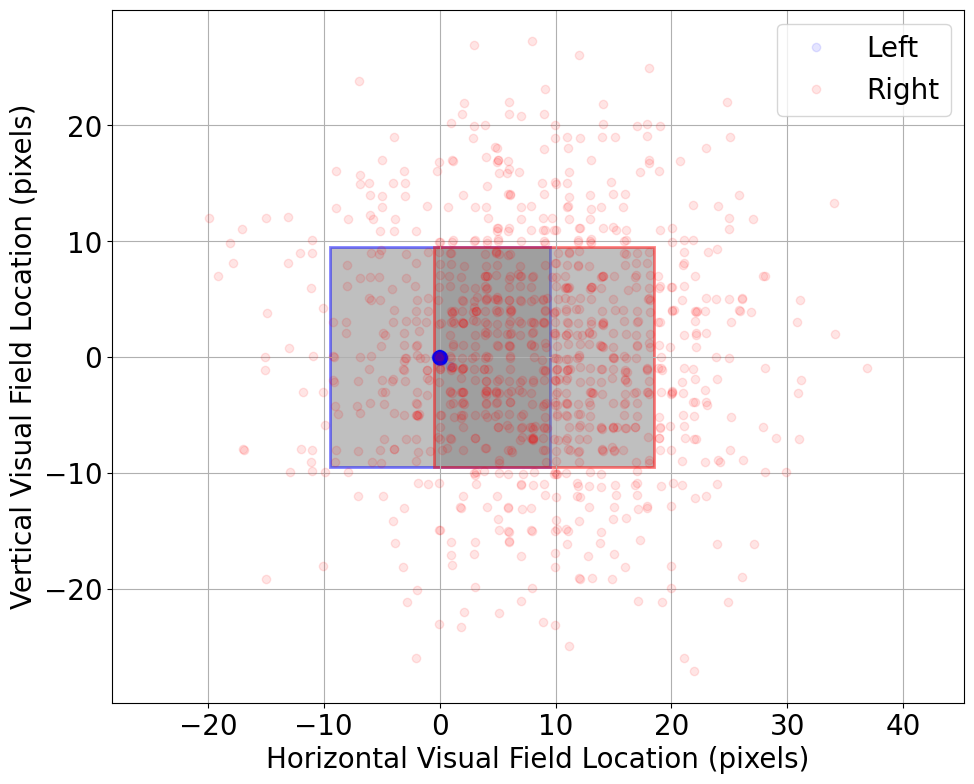

In [53]:
import matplotlib.patches as patches
ca=sim.monitors['ca'].array()
ra=sim.monitors['ra'].array()
c=sim.monitors['c'].array()
r=sim.monitors['r'].array()

N=len(ca)

ca_1=sim.monitors['ca_1'].array()
ra_1=sim.monitors['ra_1'].array()
c_1=sim.monitors['c_1'].array()
r_1=sim.monitors['r_1'].array()

figure(figsize=(11,9))
plot(ca-c+randn(N)*.1,-(ra-r)+randn(N)*.1,'bo',label='Left',alpha=0.1)

plot(ca_1-c_1+randn(N)*.1,-(ra_1-r_1)+randn(N)*.1,'ro',label='Right',alpha=0.1)
rect = patches.Rectangle((-19/2, -19/2), 19, 19, linewidth=1, edgecolor='b',lw=2, facecolor='gray',alpha=0.5)
gca().add_patch(rect)
rect = patches.Rectangle((-19/2+mu_c, -19/2-mu_r), 19, 19, linewidth=1, edgecolor='r', lw=2,facecolor='gray',alpha=0.5)
gca().add_patch(rect)
axis('equal');

xlabel('Horizontal Visual Field Location (pixels)')
ylabel('Vertical Visual Field Location (pixels)');
legend();

#savefig('fig-jitter-locations.png')


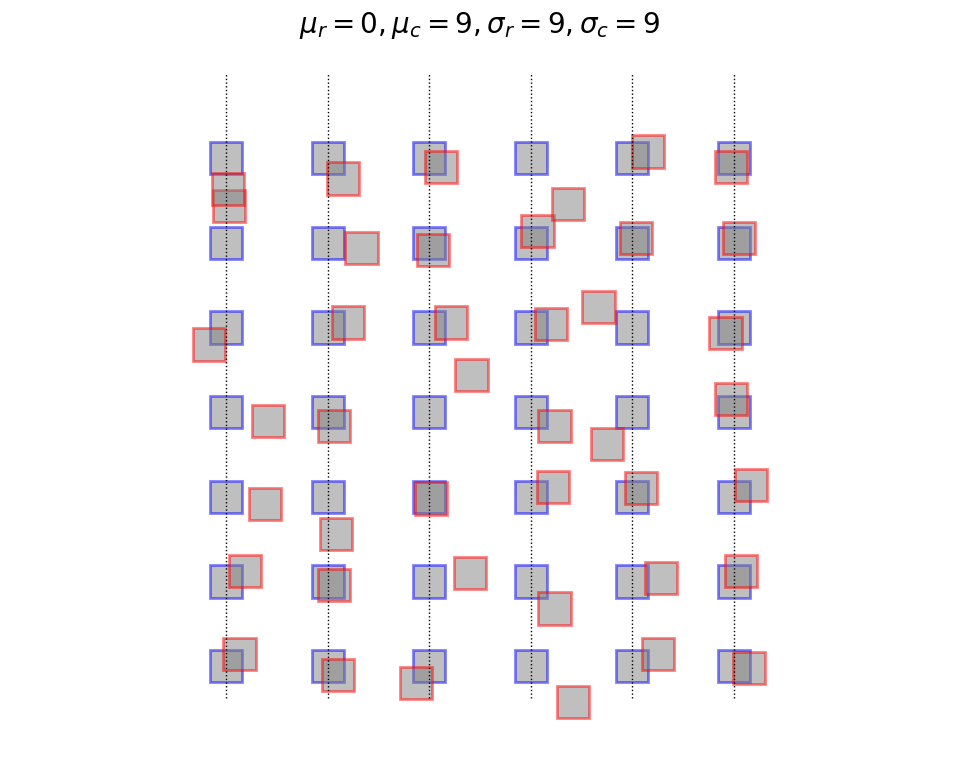

In [58]:
ca=sim.monitors['ca'].array()
ra=sim.monitors['ra'].array()
c=sim.monitors['c'].array()
r=sim.monitors['r'].array()

N=len(ca)
Nj=6
Ni=7
count=1
vertical_offset=50
for j in range(Nj):
    vlines(60*j, -19, Ni*vertical_offset, color='k', lw=1,linestyles=':')
    for i in range(Ni):
        rect = patches.Rectangle((-19/2+ca[count]-c[count]+60*j, -19/2-(ra[count]-r[count])+vertical_offset*i), 19, 19, 
                                 linewidth=1, edgecolor='b',lw=2, facecolor='gray',alpha=0.5)
        gca().add_patch(rect)
        rect = patches.Rectangle((-19/2+ca_1[count]-c_1[count]+60*j, -19/2-(ra_1[count]-r_1[count])+vertical_offset*i), 19, 19, 
                                 linewidth=1, edgecolor='r', lw=2,facecolor='gray',alpha=0.5)
        gca().add_patch(rect)
        count+=1


axis('equal');
title(rf'$\mu_r={mu_r},\mu_c={mu_c},\sigma_r={sigma_r}, \sigma_c={sigma_c}$')
axis('off')

sfname=f'RF_offsets_mu_c {mu_c} sigma_c {sigma_c} mu_r {mu_r} sigma_r {sigma_r}.pdf'
tight_layout()
plt.savefig(sfname,transparent=True)